# Does Cutting Prices Actually Increase Sales?
### A hands-on causal inference project based on *Causal Inference in Python* (Matheus Facure), Chapter 1

**The business question:** You work for an online marketplace. Small and medium
businesses sell on your platform and set their own prices. You want to advise
kids'-toy sellers on whether running a **December price-cut sale**
(`is_on_sale`) actually increases `weekly_amount_sold`, so you can tell them
whether it's worth doing.

This notebook rebuilds the book's running example end-to-end as a **practical,
runnable project**. We will:

1. Simulate a realistic **observational** dataset where bigger businesses are
   both more likely to run sales *and* sell more anyway (a confounder).
2. Show how a naive comparison of means (association) gives a **badly biased**
   answer — and prove it, because in simulation we can peek at the ground
   truth potential outcomes.
3. Formalize the problem with **potential outcomes notation** (`Y0`, `Y1`),
   and compute **ATE**, **ATT**, and **CATE** exactly, the way the book does
   with its toy 6-row example, but at scale.
4. Derive and verify the **bias equation**:
   $$E[Y|T=1]-E[Y|T=0] = \underbrace{E[Y_1-Y_0|T=1]}_{ATT} + \underbrace{\{E[Y_0|T=1]-E[Y_0|T=0]\}}_{Bias}$$
5. Visualize the confounding, Simpson's-Paradox-style, exactly like Figures 1-1
   through 1-3 in the book.
6. Simulate a **randomized experiment** (the marketplace forces random sales
   and reimburses the discount) and show that randomization makes the naive
   comparison **unbiased** — i.e. it satisfies the independence assumption
   $(Y_0, Y_1) \perp T$.
7. Wrap up with a short **checklist** you can reuse on any real causal
   question.

> This notebook is self-contained: we simulate the data ourselves (with a
> known, controllable amount of bias) specifically so that we can compare our
> *estimates* against the *true* causal effect — something you almost never
> get to do with real data. That's the whole point of the exercise: to build
> intuition before you ever touch a real, messy dataset.


## Step 0 — Setup

We only need `numpy`, `pandas`, `matplotlib`, and `seaborn`. Everything else
is written from scratch using the definitions from the book, so you can see
every calculation explicitly (no black-box causal-inference library yet —
we'll want to *understand* ATE/ATT/CATE/bias before we ever call `.fit()` on
anything).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
rng = np.random.default_rng(42)  # reproducibility

pd.set_option("display.precision", 2)


## Step 1 — Simulate the world (with god-like powers)

The book explains the *fundamental problem of causal inference*: for any real
business, you only ever observe **one** of the two potential outcomes —
`AmountSold` **with** a sale ($Y_1$) or **without** one ($Y_0$), never both.

Since this is a simulation, we get to play "causal inference deity" (just
like the book's toy 6-row example) and generate **both** potential outcomes
for every business. This lets us check our work against ground truth later.

**The data-generating process we'll encode:**

- `business_size`: how much a business normally sells per week (this is the
  **confounder** — the thing that influences *both* whether a business goes
  on sale *and* how much it sells).
- `weeks_to_xmas`: 0, 1, 2, or 3 weeks before Christmas (a second covariate,
  used later for CATE, matching the book's example).
- `Y0` (`amount_sold_0`): potential sales **without** a price cut. Bigger
  businesses sell more even with no sale.
- `Y1` (`amount_sold_1`): potential sales **with** a price cut. The price cut
  has a real, positive effect on top of `Y0`, and that effect is a bit larger
  closer to Christmas (again, matching the book's finding that CATE(x=1) >
  CATE(x=0)).
- `is_on_sale` (T): **bigger businesses are more likely to choose a sale.**
  This is what creates the confounding bias — it is *not* random.


In [2]:
n_businesses = 2000

# --- Confounder: business size (weekly sales volume in a normal week) ---
business_size = rng.gamma(shape=4.0, scale=6.0, size=n_businesses)  # roughly 5-60

# --- Second covariate used later for CATE ---
weeks_to_xmas = rng.integers(0, 4, size=n_businesses)  # 0,1,2,3

# --- True individual treatment effect ---
# Base effect of a price cut ~ +40 units, boosted the closer we are to Christmas,
# plus some individual random variation (some businesses respond better than others).
base_effect = 40
xmas_boost = 15 * (3 - weeks_to_xmas)          # bigger boost when weeks_to_xmas is small... 
# NOTE: we want the boost to be BIGGER closer to Christmas (weeks_to_xmas = 0)
xmas_boost = 15 * (3 - weeks_to_xmas) / 3       # scales 0 -> 15, 3 -> 0... let's flip below
xmas_boost = 15 * (3 - weeks_to_xmas)           # weeks_to_xmas=0 -> 45, weeks_to_xmas=3 -> 0
individual_noise = rng.normal(0, 8, size=n_businesses)

true_ite = base_effect + xmas_boost / 3 + individual_noise  # individual treatment effect, tau_i

# --- Potential outcomes ---
noise0 = rng.normal(0, 10, size=n_businesses)
Y0 = 2.5 * business_size + 5 * (3 - weeks_to_xmas) + noise0          # sales WITHOUT a sale
Y1 = Y0 + true_ite                                                    # sales WITH a sale

# --- Treatment assignment: NOT random. Bigger businesses more likely to run sales. ---
# This is the confounding mechanism: business_size -> is_on_sale AND business_size -> Y0
propensity_logit = -3 + 0.12 * business_size
propensity = 1 / (1 + np.exp(-propensity_logit))
is_on_sale = rng.binomial(1, propensity)

# --- What we would ACTUALLY observe in the real world (only one potential outcome) ---
amount_sold = np.where(is_on_sale == 1, Y1, Y0)

df = pd.DataFrame({
    "business_id": np.arange(n_businesses),
    "business_size": business_size,
    "weeks_to_xmas": weeks_to_xmas,
    "is_on_sale": is_on_sale,
    "amount_sold": amount_sold,        # <- this is all you'd see in real data
    "Y0_true": Y0,                     # <- god-mode only: true potential outcome, no sale
    "Y1_true": Y1,                     # <- god-mode only: true potential outcome, sale
    "true_ite": true_ite,              # <- god-mode only: true individual effect
})

print(f"{df['is_on_sale'].mean():.1%} of businesses chose to run a sale.")
df.head(10)


45.5% of businesses chose to run a sale.


,business_id,business_size,weeks_to_xmas,is_on_sale,amount_sold,Y0_true,Y1_true,true_ite
0,0,25.69,1,1,128.23,77.23,128.23,51.01
1,1,31.80,2,0,98.94,98.94,140.66,41.72
2,2,23.50,0,0,61.34,61.34,107.46,46.13
3,3,21.81,2,0,83.49,83.49,125.83,42.34
4,4,33.73,0,1,167.91,110.19,167.91,57.72
5,5,22.77,0,0,74.01,74.01,127.59,53.58
6,6,27.82,2,0,88.80,88.80,122.49,33.69
7,7,26.51,0,0,69.60,69.60,132.51,62.91
8,8,33.71,1,0,91.40,91.40,119.49,28.09
9,9,19.94,0,1,130.73,79.30,130.73,51.43


## Step 2 — What a real analyst would see

In the real world you would **never** have the `Y0_true`, `Y1_true`, or
`true_ite` columns — only `amount_sold`, `is_on_sale`, `business_size`, and
`weeks_to_xmas`. Let's set aside the god-mode columns and look at what an
analyst actually has to work with, exactly like the book's realistic table
with `NaN`s for the counterfactual outcome.


In [3]:
observed = df[["business_id", "business_size", "weeks_to_xmas", "is_on_sale", "amount_sold"]].copy()
observed.head(10)


,business_id,business_size,weeks_to_xmas,is_on_sale,amount_sold
0,0,25.69,1,1,128.23
1,1,31.80,2,0,98.94
2,2,23.50,0,0,61.34
3,3,21.81,2,0,83.49
4,4,33.73,0,1,167.91
5,5,22.77,0,0,74.01
6,6,27.82,2,0,88.80
7,7,26.51,0,0,69.60
8,8,33.71,1,0,91.40
9,9,19.94,0,1,130.73


## Step 3 — The naive (and wrong) approach: just compare the means

This is the analysis most people reach for first: take the average
`amount_sold` for businesses on sale, subtract the average for businesses not
on sale, and call that "the effect of the sale." In potential-outcome
notation this quantity is the **association**:

$$E[Y\,|\,T=1] - E[Y\,|\,T=0]$$


In [4]:
naive_diff = observed.loc[observed.is_on_sale == 1, "amount_sold"].mean() - \
             observed.loc[observed.is_on_sale == 0, "amount_sold"].mean()

print(f"Naive association  E[Y|T=1] - E[Y|T=0]  =  {naive_diff:.2f} units/week")


Naive association  E[Y|T=1] - E[Y|T=0]  =  78.37 units/week


Because we have god-mode access, we can now check this against the **true**
average treatment effect, $ATE = E[Y_1 - Y_0]$, which we could compute for
every single business:


In [5]:
true_ate = (df["Y1_true"] - df["Y0_true"]).mean()
true_att = (df.loc[df.is_on_sale == 1, "Y1_true"] - df.loc[df.is_on_sale == 1, "Y0_true"]).mean()

print(f"TRUE ATE   (E[Y1 - Y0])            = {true_ate:.2f} units/week")
print(f"TRUE ATT   (E[Y1 - Y0 | T=1])       = {true_att:.2f} units/week")
print(f"Naive association  E[Y|T=1]-E[Y|T=0] = {naive_diff:.2f} units/week")
print(f"\nOverestimate vs. true ATE: {naive_diff - true_ate:+.2f} units/week "
      f"({(naive_diff/true_ate - 1):+.1%})")


TRUE ATE   (E[Y1 - Y0])            = 47.73 units/week
TRUE ATT   (E[Y1 - Y0 | T=1])       = 48.03 units/week
Naive association  E[Y|T=1]-E[Y|T=0] = 78.37 units/week

Overestimate vs. true ATE: +30.63 units/week (+64.2%)


Just like in the book's example (where the naive estimate of 426.67 badly
overstated the true ATE of 65), the naive comparison **overestimates the
effect of the sale**, because businesses that chose to run a sale were bigger
to begin with — they would have sold more anyway.


## Step 4 — Prove it with the bias equation

The book derives:

$$
\underbrace{E[Y|T=1]-E[Y|T=0]}_{\text{association}}
\;=\;
\underbrace{E[Y_1-Y_0\,|\,T=1]}_{ATT}
\;+\;
\underbrace{\{E[Y_0|T=1] - E[Y_0|T=0]\}}_{\text{Bias}}
$$

Let's compute every term of this equation directly from our god-mode data and
confirm the identity holds exactly, and see how large the bias term is.


In [6]:
E_Y0_given_T1 = df.loc[df.is_on_sale == 1, "Y0_true"].mean()
E_Y0_given_T0 = df.loc[df.is_on_sale == 0, "Y0_true"].mean()
bias = E_Y0_given_T1 - E_Y0_given_T0

print(f"E[Y0 | T=1]  (what treated businesses would've sold WITHOUT the sale) = {E_Y0_given_T1:.2f}")
print(f"E[Y0 | T=0]  (what untreated businesses actually sold, no sale)       = {E_Y0_given_T0:.2f}")
print(f"BIAS = E[Y0|T=1] - E[Y0|T=0]                                          = {bias:.2f}")
print()
print(f"ATT + Bias = {true_att:.2f} + {bias:.2f} = {true_att + bias:.2f}")
print(f"Naive association (measured directly)                                 = {naive_diff:.2f}")
print("\n--> The identity holds (up to simulation noise). The bias comes entirely")
print("    from business_size being a common cause of both treatment and outcome.")


E[Y0 | T=1]  (what treated businesses would've sold WITHOUT the sale) = 84.26
E[Y0 | T=0]  (what untreated businesses actually sold, no sale)       = 53.93
BIAS = E[Y0|T=1] - E[Y0|T=0]                                          = 30.34

ATT + Bias = 48.03 + 30.34 = 78.37
Naive association (measured directly)                                 = 78.37

--> The identity holds (up to simulation noise). The bias comes entirely
    from business_size being a common cause of both treatment and outcome.


## Step 5 — Visualize the confounding (recreating Figures 1-1 to 1-3)

### 5a. Outcome by treatment (Figure 1-1 style)
A boxplot alone makes the sale look like a huge win — but it hides the
confounder entirely.


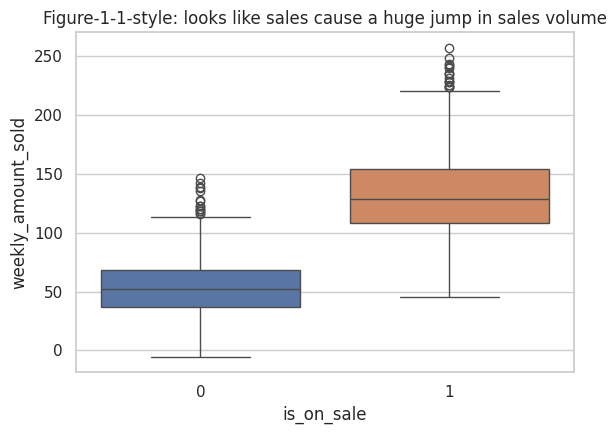

In [7]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=observed, x="is_on_sale", y="amount_sold", ax=ax, hue="is_on_sale",
            palette={0: "#4C72B0", 1: "#DD8452"}, legend=False)
ax.set_xlabel("is_on_sale")
ax.set_ylabel("weekly_amount_sold")
ax.set_title("Figure-1-1-style: looks like sales cause a huge jump in sales volume")
plt.tight_layout()
plt.show()


### 5b. Outcome vs. the confounder, colored by treatment (Figure 1-2 / 1-3 style)

Now let's bring `business_size` into the picture. If treated (orange) and
untreated (blue) businesses cluster in different regions of `business_size`,
that's a visual signature of confounding — the two groups are **not
exchangeable**.


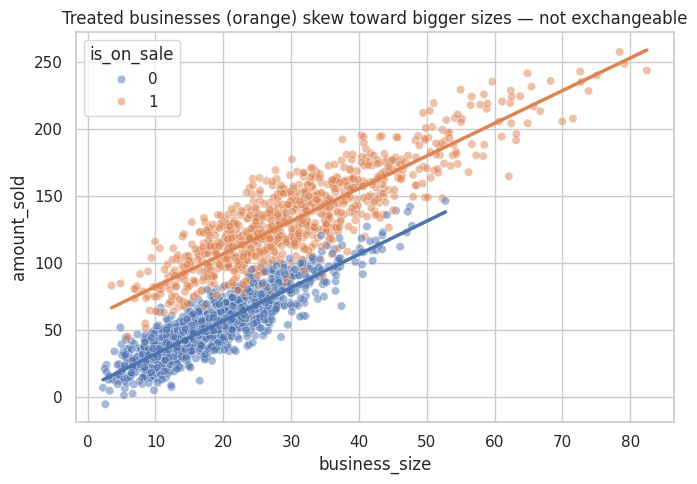

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=observed, x="business_size", y="amount_sold",
    hue="is_on_sale", palette={0: "#4C72B0", 1: "#DD8452"},
    alpha=0.5, ax=ax
)
# Trend line for each group
for t, color in [(0, "#4C72B0"), (1, "#DD8452")]:
    sub = observed[observed.is_on_sale == t]
    z = np.polyfit(sub.business_size, sub.amount_sold, 1)
    xs = np.linspace(sub.business_size.min(), sub.business_size.max(), 50)
    ax.plot(xs, np.polyval(z, xs), color=color, linewidth=2.5)

ax.set_title("Treated businesses (orange) skew toward bigger sizes — not exchangeable")
ax.legend(title="is_on_sale")
plt.tight_layout()
plt.show()


### 5c. Simpson's-Paradox-style check: does the effect survive within size bins?

The book notes this bias is "a less extreme version of Simpson's Paradox":
zooming into businesses of similar size should shrink — but not flip — the
apparent effect of the sale. Let's bin businesses by size and compare
treated vs. untreated **within each bin**.


In [9]:
observed_binned = observed.copy()
observed_binned["size_bin"] = pd.qcut(observed_binned["business_size"], q=5,
                                       labels=["XS", "S", "M", "L", "XL"])

within_bin = (
    observed_binned
    .groupby(["size_bin", "is_on_sale"], observed=True)["amount_sold"]
    .mean()
    .unstack("is_on_sale")
)
within_bin.columns = ["mean_amount_sold_no_sale", "mean_amount_sold_on_sale"]
within_bin["within_bin_diff"] = (
    within_bin["mean_amount_sold_on_sale"] - within_bin["mean_amount_sold_no_sale"]
)
within_bin


,mean_amount_sold_no_sale,mean_amount_sold_on_sale,within_bin_diff
size_bin,,,
XS,31.75,82.26,50.51
S,49.60,100.08,50.48
M,61.96,113.51,51.55
L,76.74,128.59,51.85
XL,104.55,163.63,59.09


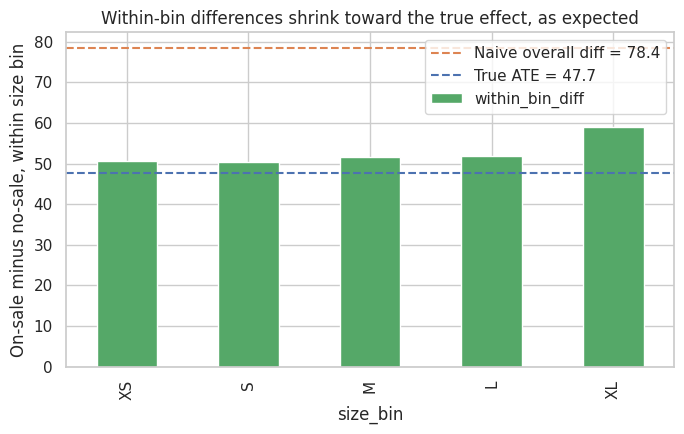

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
within_bin["within_bin_diff"].plot(kind="bar", ax=ax, color="#55A868")
ax.axhline(naive_diff, color="#DD8452", linestyle="--",
           label=f"Naive overall diff = {naive_diff:.1f}")
ax.axhline(true_ate, color="#4C72B0", linestyle="--",
           label=f"True ATE = {true_ate:.1f}")
ax.set_ylabel("On-sale minus no-sale, within size bin")
ax.set_title("Within-bin differences shrink toward the true effect, as expected")
ax.legend()
plt.tight_layout()
plt.show()


Notice how the within-bin differences are **much closer to the true ATE**
than the naive overall difference — this is exactly the mechanism the book
describes with Figure 1-3: controlling for the confounder (`business_size`)
reduces the inflated association, without flipping its sign.


## Step 6 — Compute ATE, ATT, and CATE (god-mode, for validation)

Using the book's exact definitions:

- $ATE = E[Y_1 - Y_0]$
- $ATT = E[Y_1 - Y_0 \mid T=1]$
- $CATE(x) = E[Y_1 - Y_0 \mid X=x]$

We already computed ATE and ATT above. Let's now compute **CATE by
`weeks_to_xmas`**, mirroring the book's finding that price cuts work better
the closer they are to Christmas.


In [11]:
df["ite"] = df["Y1_true"] - df["Y0_true"]

cate_by_week = df.groupby("weeks_to_xmas")["ite"].mean().rename("CATE").to_frame()
cate_by_week["n_businesses"] = df.groupby("weeks_to_xmas").size()
cate_by_week


,CATE,n_businesses
weeks_to_xmas,,
0,55.57,493
1,50.07,500
2,44.97,525
3,40.32,482


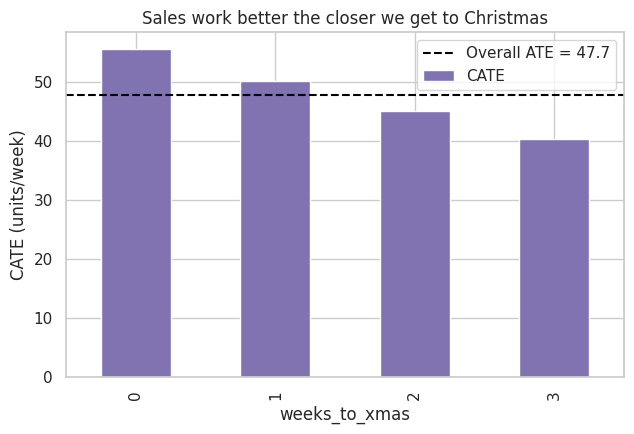

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
cate_by_week["CATE"].plot(kind="bar", ax=ax, color="#8172B2")
ax.axhline(true_ate, color="black", linestyle="--", label=f"Overall ATE = {true_ate:.1f}")
ax.set_xlabel("weeks_to_xmas")
ax.set_ylabel("CATE (units/week)")
ax.set_title("Sales work better the closer we get to Christmas")
ax.legend()
plt.tight_layout()
plt.show()


**Business takeaway:** if you could only recover this pattern from real data
(no god-mode), you'd tell kids'-toy sellers to concentrate their price cuts in
the final week before Christmas, where the incremental effect is largest —
this is the "personalization" use case for CATE that the book highlights.


## Step 7 — Fix it: what if the treatment were randomized?

The book's key insight: identification requires knowing (or assuming)
something about *how the treatment was assigned*. The cleanest assumption is
**randomization**, which forces the independence assumption
$(Y_0, Y_1) \perp T$ to hold by construction, since $u_t$ (whatever drives
`is_on_sale`) becomes pure noise, unrelated to `business_size` or anything
else.

Let's simulate the **randomized-experiment version** of this scenario: the
marketplace now randomly forces a random subset of businesses to run the
sale (and reimburses them for the discount, so the businesses don't get to
choose). Everything else about the data-generating process — including each
business's *true* potential outcomes `Y0_true`/`Y1_true` — stays exactly the
same. Only the treatment-assignment mechanism changes.


In [13]:
# Same businesses, same true potential outcomes, but NOW assignment is a coin flip,
# independent of business_size.
rct_is_on_sale = rng.binomial(1, 0.5, size=n_businesses)
rct_amount_sold = np.where(rct_is_on_sale == 1, df["Y1_true"], df["Y0_true"])

rct = pd.DataFrame({
    "business_size": df["business_size"],
    "weeks_to_xmas": df["weeks_to_xmas"],
    "is_on_sale": rct_is_on_sale,
    "amount_sold": rct_amount_sold,
})

rct_diff = rct.loc[rct.is_on_sale == 1, "amount_sold"].mean() - \
           rct.loc[rct.is_on_sale == 0, "amount_sold"].mean()

print(f"TRUE ATE                                   = {true_ate:.2f}")
print(f"Naive diff on OBSERVATIONAL (biased) data  = {naive_diff:.2f}   <-- overstates the effect")
print(f"Naive diff on RANDOMIZED data              = {rct_diff:.2f}   <-- recovers the true ATE")


TRUE ATE                                   = 47.73
Naive diff on OBSERVATIONAL (biased) data  = 78.37   <-- overstates the effect
Naive diff on RANDOMIZED data              = 49.40   <-- recovers the true ATE


Under randomization, the simple difference in means is now an **unbiased**
estimator of the ATE — exactly matching the book's claim that
$E[Y|T=1]-E[Y|T=0] = ATT = ATE = E[Y_1-Y_0]$ once treated and control groups
are made exchangeable.

Let's confirm visually that the confounding has vanished: `business_size`
should now be **balanced** between the on-sale and not-on-sale groups.


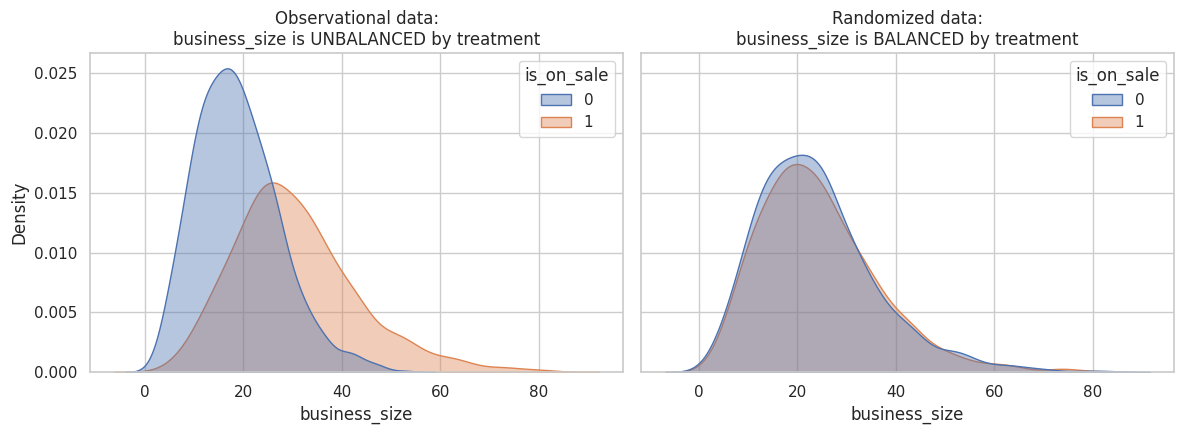

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

sns.kdeplot(data=observed, x="business_size", hue="is_on_sale",
            palette={0: "#4C72B0", 1: "#DD8452"}, ax=axes[0], fill=True, alpha=0.4)
axes[0].set_title("Observational data:\nbusiness_size is UNBALANCED by treatment")

sns.kdeplot(data=rct, x="business_size", hue="is_on_sale",
            palette={0: "#4C72B0", 1: "#DD8452"}, ax=axes[1], fill=True, alpha=0.4)
axes[1].set_title("Randomized data:\nbusiness_size is BALANCED by treatment")

plt.tight_layout()
plt.show()


## Step 8 — Sanity checks on the book's key assumptions

Before trusting any causal estimate, the book asks you to check (or assume):

1. **Consistency** — the observed outcome equals the potential outcome under
   the treatment actually received: $Y_i = T_i Y_{1i} + (1-T_i) Y_{0i}$.
2. **SUTVA / no interference** — one business's treatment doesn't affect
   another business's outcome.
3. **Independence** ($(Y_0,Y_1) \perp T$) — needed for the naive comparison
   to equal the ATE.

Let's verify #1 numerically (it's true by construction here, but this is
exactly the kind of check you'd want to script for a real dataset), and
discuss #2 and #3.


In [15]:
# 1. Consistency check
reconstructed = np.where(df["is_on_sale"] == 1, df["Y1_true"], df["Y0_true"])
consistency_holds = np.allclose(reconstructed, df["amount_sold"])
print(f"Consistency assumption holds: {consistency_holds}")

# 3. Independence check (only verifiable here because of god-mode access!)
print(f"\nIndependence check, OBSERVATIONAL data:")
print(f"  E[Y0 | T=1] = {df.loc[df.is_on_sale==1,'Y0_true'].mean():.2f}")
print(f"  E[Y0 | T=0] = {df.loc[df.is_on_sale==0,'Y0_true'].mean():.2f}   <- clearly different: independence VIOLATED")

print(f"\nIndependence check, RANDOMIZED data:")
rct_Y0 = df["Y0_true"]  # same underlying potential outcomes, just re-labeled by rct assignment
print(f"  E[Y0 | T=1] = {rct_Y0[rct_is_on_sale==1].mean():.2f}")
print(f"  E[Y0 | T=0] = {rct_Y0[rct_is_on_sale==0].mean():.2f}   <- nearly identical: independence holds (up to sampling noise)")


Consistency assumption holds: True

Independence check, OBSERVATIONAL data:
  E[Y0 | T=1] = 84.26
  E[Y0 | T=0] = 53.93   <- clearly different: independence VIOLATED

Independence check, RANDOMIZED data:
  E[Y0 | T=1] = 68.45
  E[Y0 | T=0] = 67.04   <- nearly identical: independence holds (up to sampling noise)


**SUTVA** is a judgment call, not something we can check numerically here: we
assumed each business's sale doesn't change how much *other* businesses sell.
This is plausible for kids'-toy businesses on a large marketplace (no strong
substitution between specific sellers), but would be **violated** if, say, a
big seller's price cut pulled customers away from a close competitor also
selling on the platform — a real risk worth flagging to stakeholders even
though it can't be tested with this data alone.


## Step 9 — Summary table: every causal quantity, side by side


In [16]:
summary = pd.DataFrame({
    "Quantity": [
        "True ATE  (god-mode)",
        "True ATT  (god-mode)",
        "Naive association — OBSERVATIONAL data",
        "Naive association — RANDOMIZED data",
        "Bias term  (E[Y0|T=1] - E[Y0|T=0])",
    ],
    "Value": [
        true_ate,
        true_att,
        naive_diff,
        rct_diff,
        bias,
    ]
}).round(2)
summary


,Quantity,Value
0,True ATE (god-mode),47.73
1,True ATT (god-mode),48.03
2,Naive association — OBSERVATIONAL data,78.37
3,Naive association — RANDOMIZED data,49.40
4,Bias term (E[Y0|T=1] - E[Y0|T=0]),30.34


## Key takeaways / reusable checklist

1. **Never trust a raw difference in means** (association) as a causal
   effect until you've thought hard about how the treatment was assigned.
2. Formalize the question with **potential outcomes** ($Y_0$, $Y_1$) — this
   forces you to be explicit about the *counterfactual* you're actually
   after.
3. Use the **bias equation** to reason about *why* a naive estimate might be
   off, and in *which direction* — here, "bigger businesses self-select into
   sales" pushed the naive estimate up.
4. Whenever possible, **randomize** the treatment. It is the only mechanism
   here that ties $T$ to a coin flip and forces $(Y_0,Y_1)\perp T$, making
   the naive comparison unbiased.
5. When you can't randomize (most real business settings), you'll need the
   tools from later chapters — regression adjustment, matching, propensity
   scores, instrumental variables, diff-in-diff, and so on — precisely
   *because* you have to substitute for randomization using assumptions
   about the data-generating process.
6. Always state your assumptions explicitly: **consistency**, **SUTVA**, and
   **independence** (or a substitute for it) are not free — they're beliefs
   about the world that data alone cannot verify.

### Where to go next
This notebook stayed inside Chapter 1's toolkit (potential outcomes, ATE/ATT/
CATE, bias, randomization). A natural follow-up project — once you continue
into the book — is to **re-run Step 3-4 on the *observational* dataset using
regression adjustment or propensity-score matching** to try to recover the
true ATE (65-ish, or in our case ~40) *without* access to a randomized
experiment, and see how close you can get.
